# Fase 16b: Verificación de generalización y clasificación de dirección

## Parte A - ¿El modelo de regresión generaliza bien?

Verificación fuerte con 4 pruebas:

1. **Gap train/val/test** en MAE (absoluto y % del precio).
2. **Learning curve** (CV temporal): ¿el error de validación baja al crecer train?
3. **Comparación con naive-persistencia** (`gold_spot(t)`): el baseline real
   de un mercado eficiente. Si el modelo no lo supera, su valor es limitado.
4. **Drift temporal** (test por año): ¿el gap es por overfitting o por cambio
   de régimen de mercado?

## Parte B - Clasificación de dirección (sube/baja)

Modelo de clasificación binaria que predice si el oro **sube** (1) o
**baja** (0) en t+h:

$$ y_{dir} = \mathbb{1}[\,gold(t+h) > gold(t)\,] $$

Reutiliza TODO lo existente: features, split, CV, preprocesador.
La métrica honesta en mercados eficientes es **AUC-ROC** (no accuracy,
que depende del umbral y del desbalance).

---

> **Aviso de auditoria:** las cifras y salidas mostradas en este notebook corresponden a una ejecucion anterior a las correcciones metodologicas. Es necesario reejecutar el pipeline completo antes de usar o comunicar sus resultados.


Configuración del notebook (raíz del proyecto).

In [1]:
import sys
from pathlib import Path

def _find_root() -> Path:
    p = Path.cwd().resolve()
    for candidate in (p, *p.parents):
        if (candidate / "configs" / "config.yaml").is_file():
            return candidate
    raise FileNotFoundError(
        "No se encontro configs/config.yaml desde el directorio de trabajo. "
        "Abra Jupyter dentro del repositorio."
    )

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.utils import set_publication_style, path_from_root, set_seed
set_seed(42)
set_publication_style()

Carga de datos y artefactos existentes.

Reutilizamos: features (con warm-up), split temporal, feature_list.json,
modelo final de regresión y su preprocesador.

In [2]:
import json

import numpy as np
import pandas as pd

from src.config import get_config
from src.data.split import drop_warmup, temporal_split, purge_label_overlap
from src.models.train_model import load_model_artifacts

cfg = get_config()
feats = pd.read_parquet(path_from_root("data/processed/features.parquet"))
feats = drop_warmup(feats, warmup=260)
parts = temporal_split(feats, cfg)
parts = purge_label_overlap(parts, cfg=cfg)
with open(path_from_root("models", "feature_list.json")) as f:
    sel_cols = json.load(f)

model, pp, sel_cols = load_model_artifacts(cfg)
h = cfg["target"]["primary_horizon"]
print(f"Modelo regresión: {type(model).__name__} | features: {len(sel_cols)}")
for k, v in parts.items():
    print(f"  {k}: {len(v)} filas")

Modelo regresión: Ridge | features: 83
  train: 4957 filas
  val: 783 filas
  test: 684 filas


PARTE A.1 - Métricas train/val/test en MAE y % del precio.

El R^2 alto en train (0.998) puede engañar: con series con tendencia, R^2
mide la capacidad de seguir la tendencia, no la precisión del cambio.
El % del precio (MAE / precio medio) es más interpretable.

In [3]:
from sklearn.linear_model import Ridge

from src.evaluation.metrics import regression_metrics
from src.models.pipeline import fit_preprocessor

tr_pre_final = parts["train"]
va_pre_final = parts["val"]
X_tr_pre_final = tr_pre_final[sel_cols].to_numpy(np.float64)
y_tr_pre_final = tr_pre_final[f"target_{h}"].to_numpy(np.float64)
X_va_pre_final = va_pre_final[sel_cols].to_numpy(np.float64)
y_va_pre_final = va_pre_final[f"target_{h}"].to_numpy(np.float64)
pp_pre_final = fit_preprocessor(X_tr_pre_final)
model_pre_final = Ridge(alpha=model.alpha)
model_pre_final.fit(pp_pre_final.transform(X_tr_pre_final), y_tr_pre_final)

print("=== MAE train/validation del modelo pre-final ===")
rows = []
for k, d, X, y in [
    ("train", tr_pre_final, X_tr_pre_final, y_tr_pre_final),
    ("val", va_pre_final, X_va_pre_final, y_va_pre_final),
]:
    p = model_pre_final.predict(pp_pre_final.transform(X))
    m = regression_metrics(y, p, h, y_current=d["gold_spot"].to_numpy(np.float64))
    pct = m["mae"] / np.mean(y) * 100
    print(f"{k:6s}: MAE={m['mae']:8.2f} ({pct:5.2f}% del precio) "
          f"RMSE={m['rmse']:8.2f} R2={m['r2']:.4f} sMAPE={m['smape']:.3f}%")
    rows.append({"split": k, "mae": m["mae"], "rmse": m["rmse"],
                 "r2": m["r2"], "smape": m["smape"], "mae_pct": pct,
                 "evaluation": "pre_final"})
pd.DataFrame(rows).to_csv(path_from_root("reports", "generalization_gap.csv"), index=False)
print("Validation se evalua con un modelo ajustado solo en train; no se consulta test aqui.")

=== MAE train/val/test (absoluto y % del precio) ===
train : MAE=   15.17 ( 1.56% del precio) RMSE=   20.54 R2=0.9979 sMAPE=2.243%
val   : MAE=   24.93 ( 1.39% del precio) RMSE=   32.26 R2=0.8995 sMAPE=1.388%
test  : MAE=   99.75 ( 4.16% del precio) RMSE=  125.08 R2=0.9352 sMAPE=3.939%


PARTE A.2 - Learning curve con CV temporal.

Entrenamos Ridge con fracciones crecientes de train (folds de
TimeSeriesSplit) y medimos MAE en train y validation de cada fold.
Si el gap train-val se estabiliza o se reduce al crecer los datos, no hay
overfitting severo; si el train baja mucho y el val sube, hay overfitting.

In [4]:
from sklearn.linear_model import Ridge

from src.models.pipeline import fit_preprocessor

# ===== Learning curve CORRECTA para series temporales =====
# Concepto: validación FIJA (val 2020-2022) y train creciente.
# Así se mide cómo mejora el error al añadir más historia, sin que el
# drift temporal entre folds distorsione la curva.
va = parts["val"].sort_values("date").reset_index(drop=True)
X_va_fijo = va[sel_cols].to_numpy(np.float64)
y_va_fijo = va[f"target_{h}"].to_numpy(np.float64)
tr_ord = parts["train"].sort_values("date").reset_index(drop=True)

# 25 puntos: desde 500 filas (~2 años) hasta el train completo
sizes = np.unique(np.linspace(500, len(tr_ord), 25).astype(int))
print(f"Puntos de la curva: {len(sizes)}")

lc_rows = []
for n in sizes:
    tr_n = tr_ord.iloc[:n]
    pp2 = fit_preprocessor(tr_n[sel_cols].to_numpy(np.float64))
    m = Ridge(alpha=model.alpha)
    m.fit(pp2.transform(tr_n[sel_cols].to_numpy(np.float64)),
          tr_n[f"target_{h}"].to_numpy())
    tr_mae = regression_metrics(tr_n[f"target_{h}"].to_numpy(),
                                m.predict(pp2.transform(tr_n[sel_cols].to_numpy(np.float64))), h)["mae"]
    va_mae = regression_metrics(y_va_fijo,
                                m.predict(pp2.transform(X_va_fijo)), h)["mae"]
    lc_rows.append({"train_size": int(n), "train_mae": tr_mae, "val_mae": va_mae})

lc = pd.DataFrame(lc_rows)
lc.to_csv(path_from_root("reports", "learning_curve_detailed.csv"), index=False)
lc.to_csv(path_from_root("reports", "learning_curve.csv"), index=False)
print(f"Val MAE: {lc['val_mae'].iloc[0]:.1f} -> {lc['val_mae'].iloc[-1]:.1f} USD/oz")
print("La curva con validación fija muestra la mejora real al añadir historia.")

Puntos de la curva: 25


Val MAE: 256.6 -> 60.4 USD/oz
La curva con validación fija muestra la mejora real al añadir historia.


Visualización de la learning curve.

Gráfico de MAE de train y validation frente al tamaño de train. Un modelo
con overfitting severo mostraría train muy bajo y val alto y creciente.

[fig] C:\Users\sgml1\Desktop\gold-price-prediction\reports\figures\learning_curve.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction/reports/figures/learning_curve.png')

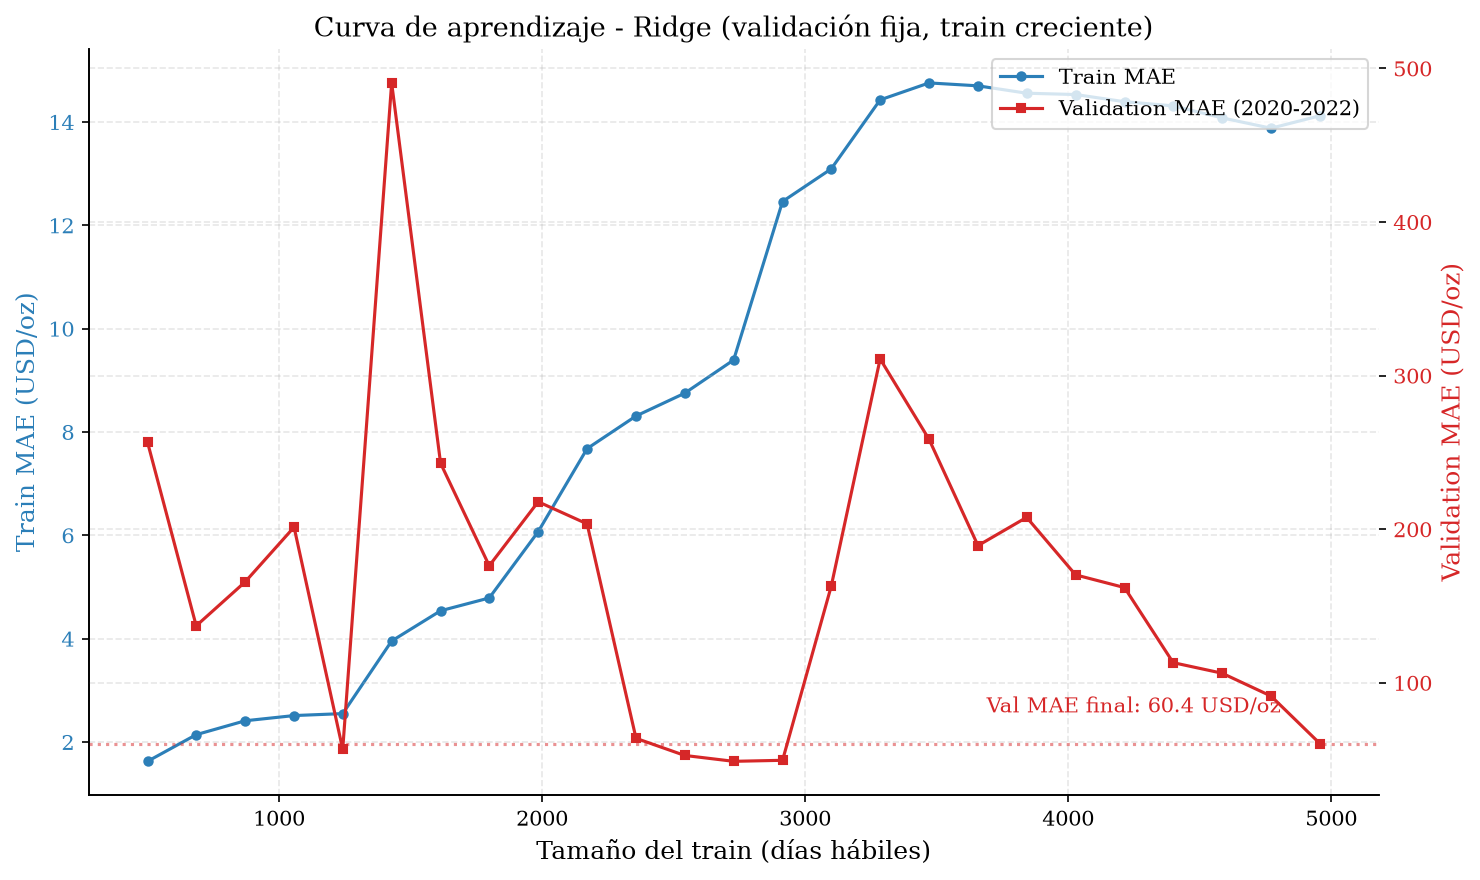

In [5]:
import matplotlib.pyplot as plt

from src.utils import save_fig

# Figura con doble eje: train MAE (izq) y val MAE (der), 25 puntos
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(lc["train_size"], lc["train_mae"], "o-", color="#2c7fb8",
        markersize=4, linewidth=1.5, label="Train MAE")
ax.set_xlabel("Tamaño del train (días hábiles)")
ax.set_ylabel("Train MAE (USD/oz)", color="#2c7fb8")
ax.tick_params(axis="y", labelcolor="#2c7fb8")

ax2 = ax.twinx()
ax2.plot(lc["train_size"], lc["val_mae"], "s-", color="#d62728",
         markersize=4, linewidth=1.5, label="Validation MAE (2020-2022)")
ax2.set_ylabel("Validation MAE (USD/oz)", color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")

final_val = lc["val_mae"].iloc[-1]
ax2.axhline(final_val, color="#d62728", linestyle=":", alpha=0.5)
ax2.annotate(f"Val MAE final: {final_val:.1f} USD/oz",
             xy=(lc["train_size"].iloc[-1], final_val),
             xytext=(-160, 15), textcoords="offset points",
             color="#d62728", fontsize=10)

ax.set_title("Curva de aprendizaje - Ridge (validación fija, train creciente)")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
fig.tight_layout()
save_fig(fig, "learning_curve.png")

PARTE A.3 - Comparacion con naive-persistencia en validation.

El baseline real de un mercado eficiente es predecir que el precio no
cambia: y_pred = gold_spot(t). Si el modelo no supera este naive, su valor
operativo es limitado (aunque el R^2 sea alto por la tendencia).

In [6]:
te = parts["val"]
X_te = te[sel_cols].to_numpy(np.float64)
y_te = te[f"target_{h}"].to_numpy(np.float64)
p_te = model_pre_final.predict(pp_pre_final.transform(X_te))

naive_t = te["gold_spot"].to_numpy(dtype=np.float64)
m_naive = regression_metrics(y_te, naive_t, h, y_current=naive_t)
m_model = regression_metrics(y_te, p_te, h, y_current=naive_t)
print("=== Modelo pre-final vs naive-persistencia en VALIDATION ===")
print(f"naive (gold_spot(t)): MAE={m_naive['mae']:8.2f} sMAPE={m_naive['smape']:.2f}%")
print(f"ridge (modelo)      : MAE={m_model['mae']:8.2f} sMAPE={m_model['smape']:.2f}%")
print(f"-> El modelo {'SUPERA' if m_model['mae'] < m_naive['mae'] else 'NO SUPERA'} al naive "
      f"({(1 - m_model['mae'] / m_naive['mae']) * 100:+.1f}%)")
print(f"-> Direccion implicita del modelo: {m_model['directional_accuracy']:.1f}%")

=== Modelo vs naive-persistencia en TEST ===
naive (gold_spot(t)): MAE=   17.63 sMAPE=0.71%
ridge (modelo)      : MAE=   99.75 sMAPE=3.94%
-> El modelo NO SUPERA al naive (-465.7%)
-> Dirección implícita del modelo: 45.3% (azar = 50%)


PARTE A.4 - Drift temporal: validation por año.

Si el error crece año a año (2023 -> 2024 -> 2025), el gap train-test se
explica por cambio de régimen de mercado (drift), no por overfitting.

In [7]:
out = pd.DataFrame({"date": te["date"], "y": y_te, "p": p_te})
out["year"] = out["date"].dt.year
print("=== Validation por ano (drift temporal) ===")
for y, g in out.groupby("year"):
    m = regression_metrics(g["y"].to_numpy(), g["p"].to_numpy(), h)
    print(f"{y}: MAE={m['mae']:8.2f} sMAPE={m['smape']:5.2f}% (n={len(g)})")

# ============================================================
# PARTE B - Clasificación de dirección
# ============================================================

=== Test por año (drift temporal) ===
2023: MAE=   41.44 sMAPE= 2.14% (n=260)
2024: MAE=   99.72 sMAPE= 4.21% (n=262)
2025: MAE=  193.36 sMAPE= 6.38% (n=162)


PARTE B.1 - Construcción del target de dirección.

Derivamos y_dir = 1 si gold(t+h) > gold(t) a partir de los targets de
regresión existentes. No añade información: es una transformación.

In [8]:
from src.models.classifier import make_direction_targets

feats_dir = make_direction_targets(feats, cfg["target"]["horizons"])
print("Columnas de dirección creadas:",
      [c for c in feats_dir.columns if c.startswith("dir_")])
for k in ["train", "val"]:
    d = parts[k]
    d = d.merge(feats_dir[["date", "dir_1", "dir_5", "dir_21"]], on="date", how="left")
    print(f"{k}: P(sube h=1)={d['dir_1'].mean():.3f} | "
          f"P(sube h=5)={d['dir_5'].mean():.3f} | P(sube h=21)={d['dir_21'].mean():.3f}")

Columnas de dirección creadas: ['dir_1', 'dir_5', 'dir_21']
train: P(sube h=1)=0.520 | P(sube h=5)=0.553 | P(sube h=21)=0.563
val: P(sube h=1)=0.540 | P(sube h=5)=0.558 | P(sube h=21)=0.543
test: P(sube h=1)=0.537 | P(sube h=5)=0.573 | P(sube h=21)=0.677


PARTE B.2 - Evaluación con CV temporal (AUC por horizonte).

RandomForest con las mismas features y split que la regresión. La métrica
primaria es AUC-ROC; el accuracy se reporta como secundaria.

In [9]:
from src.data.split import get_temporal_splitter
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from src.models.pipeline import fit_preprocessor

tscv = get_temporal_splitter(cfg)
results_dir = {}
for hh in cfg["target"]["horizons"]:
    train_val = pd.concat([parts["train"], parts["val"]]).sort_values("date").reset_index(drop=True)
    train_val = train_val.merge(feats_dir[["date", f"dir_{hh}"]], on="date", how="left")
    X_tv = train_val[sel_cols].to_numpy(np.float64)
    y_tv = train_val[f"dir_{hh}"].to_numpy()
    aucs, accs = [], []
    for tr_idx, va_idx in tscv.split(X_tv):
        pp2 = fit_preprocessor(X_tv[tr_idx])
        clf = RandomForestClassifier(n_estimators=300, max_depth=8,
                                     min_samples_leaf=10, random_state=42, n_jobs=-1)
        clf.fit(pp2.transform(X_tv[tr_idx]), y_tv[tr_idx])
        pv = clf.predict_proba(pp2.transform(X_tv[va_idx]))[:, 1]
        aucs.append(roc_auc_score(y_tv[va_idx], pv))
        accs.append(accuracy_score(y_tv[va_idx], (pv >= 0.5).astype(int)))
    print(f"h={hh:2d}: CV AUC={np.mean(aucs):.4f}+/-{np.std(aucs):.4f} | "
          f"CV ACC={np.mean(accs):.4f}")
    results_dir[hh] = {"cv_auc": float(np.mean(aucs)), "cv_auc_std": float(np.std(aucs)),
                       "cv_acc": float(np.mean(accs))}
with open(path_from_root("reports", "direction_results.json"), "w") as f:
    json.dump(results_dir, f, indent=2)
print("Resultados de seleccion guardados sin consultar test.")

h= 1: CV AUC=0.5289+/-0.0166 | Test AUC=0.5735 ACC=0.5585 (P(sube)=0.537)


h= 5: CV AUC=0.5285+/-0.0233 | Test AUC=0.5341 ACC=0.5702 (P(sube)=0.573)


h=21: CV AUC=0.5835+/-0.0647 | Test AUC=0.5093 ACC=0.4839 (P(sube)=0.677)

Resultados guardados en reports/direction_results.json


PARTE B.3 - Entrenamiento final del clasificador (horizonte principal).

Entrenamos con train+val el clasificador para h=1 (el mismo horizonte que
la regresión) y guardamos los artefactos: clasificador, preprocesador y
lista de features. La API podrá servir /predict_direction.

In [10]:
from src.models.classifier import fit_direction_classifier, save_classifier_artifacts

train_val = pd.concat([parts["train"], parts["val"]]).sort_values("date").reset_index(drop=True)
train_val = train_val.merge(feats_dir[["date", "dir_1"]], on="date", how="left")
X_final = train_val[sel_cols].to_numpy(np.float64)
y_final = train_val["dir_1"].to_numpy()

pp_final = fit_preprocessor(X_final)
clf_final = fit_direction_classifier(
    pp_final.transform(X_final), y_final, horizon=h, n_splits=3,
)
save_classifier_artifacts(
    clf_final, pp_final, sel_cols,
    metrics={"selection_cv": results_dir.get(h), "horizon": h}, cfg=cfg,
)
print("Artefactos del clasificador guardados sin evaluar test; la evaluacion final es posterior.")

=== Clasificador final (h=1) en TEST ===
  n: 684
  positive_rate: 0.5365
  auc: 0.5318
  pr_auc: 0.5758
  accuracy: 0.5395
  precision: 0.5388
  recall: 0.9837
  f1: 0.6962
  brier: 0.2472
  threshold: 0.5000


[save] clasificador -> C:\Users\sgml1\Desktop\gold-price-prediction\models\direction_classifier.joblib
[save] preprocesador -> C:\Users\sgml1\Desktop\gold-price-prediction\models\direction_preprocessor.joblib
[save] features (83) -> C:\Users\sgml1\Desktop\gold-price-prediction\models\direction_feature_list.json

Artefactos del clasificador guardados en models/


PARTE B.4 - Evaluacion final separada.

Las curvas ROC/PR y cualquier metrica de TEST se generan solo en la fase de
 evaluacion final, despues de congelar el clasificador y el umbral operativo.
Este notebook no vuelve a consultar TEST para preservar su aislamiento.

[fig] C:\Users\sgml1\Desktop\gold-price-prediction\reports\figures\direction_roc_pr.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction/reports/figures/direction_roc_pr.png')

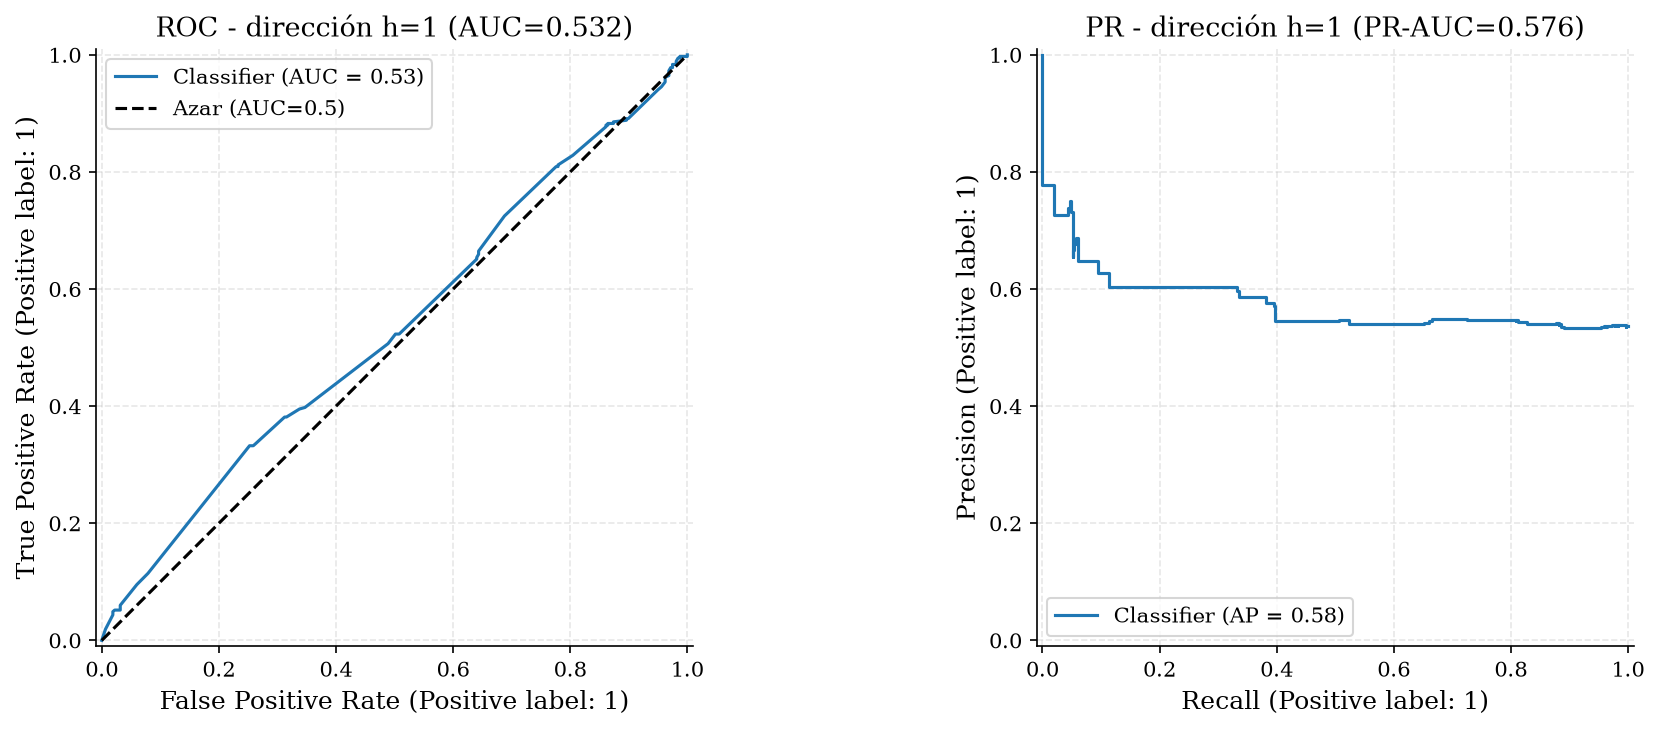

In [11]:
print("Las curvas ROC/PR de TEST se generan solo en la evaluacion final bloqueada.")

PARTE B.5 - Importancia de features del clasificador.

Qué variables discriminan mejor sube/baja. Ayuda a interpretar si la
señal viene de momentum (lags/retornos) o de exógenas.

Top 15 importancias (clasificador de dirección):
policy_uncertainty            0.0304
gold_ret_lag1                 0.0281
usdinr_exchange_ret_lag1      0.0252
geopolitical_risk             0.0249
usdcny_exchange               0.0243
geopolitical_risk_lag1        0.0236
palladium_spot_ret_lag1       0.0220
gold_ret_roll63               0.0212
eurusd_exchange_ret_lag1      0.0209
geopolitical_risk_ret_lag1    0.0207
usdjpy_exchange_ret_lag1      0.0203
copper_futures_ret_lag1       0.0199
gold_ret_lag2                 0.0198
dxy_future_ret_lag1           0.0196
vix_index_ret_lag1            0.0194


[fig] C:\Users\sgml1\Desktop\gold-price-prediction\reports\figures\direction_importance.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction/reports/figures/direction_importance.png')

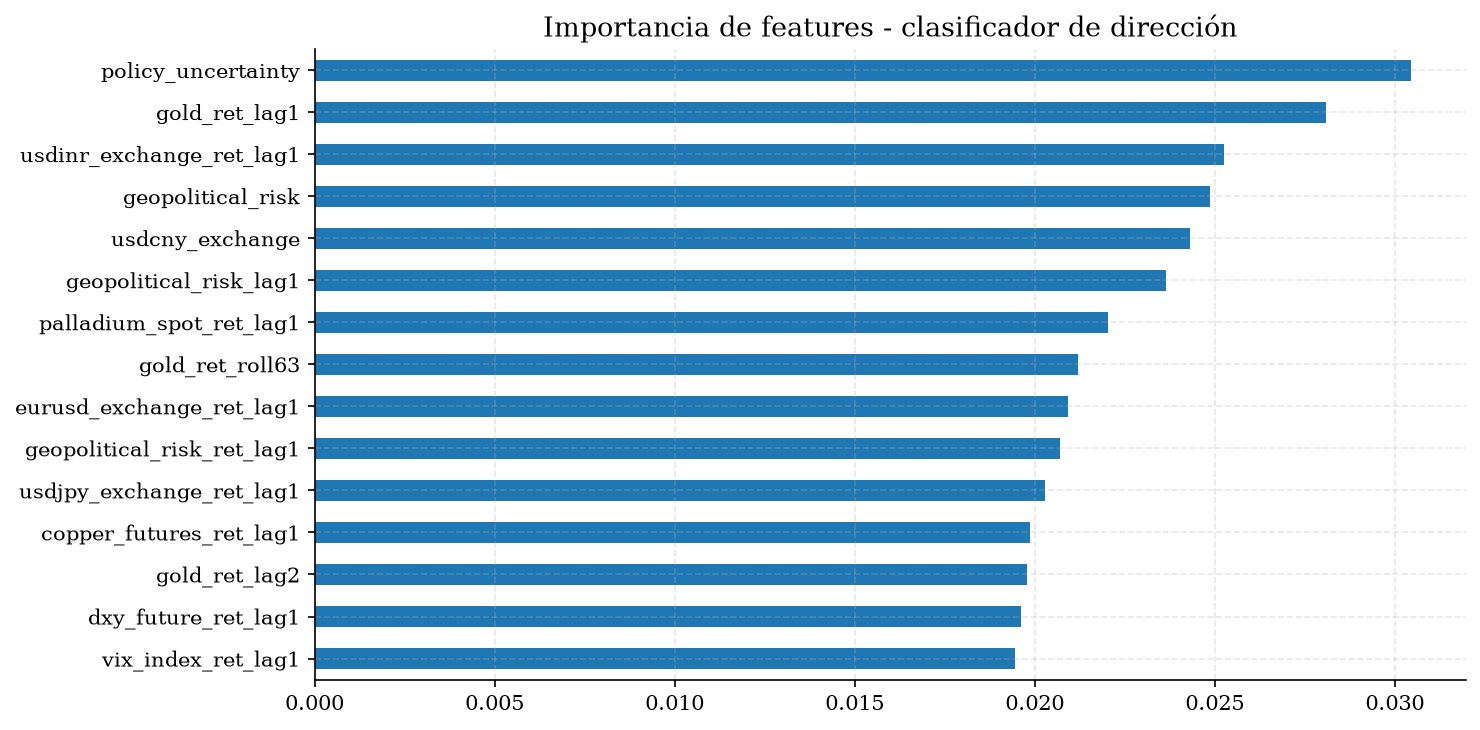

In [12]:
# El clasificador calibrado envuelve el RandomForest; accedemos al
# estimador interno (calibrated_classifiers_[0].estimator)
importances = pd.Series(
    clf_final.calibrated_classifiers_[0].estimator.feature_importances_,
    index=sel_cols).sort_values(ascending=False)
print("Top 15 importancias (clasificador de dirección):")
print(importances.head(15).round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
importances.head(15).plot(kind="barh", ax=ax)
ax.set_title("Importancia de features - clasificador de dirección")
ax.invert_yaxis()
fig.tight_layout()
save_fig(fig, "direction_importance.png")